In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- System setup ----------
dsep = 0.5
snr0_dB = 10
snr1_dB = 10
sigma_N0 = 10**(-0.1 * snr0_dB)
sigma_N1 = sigma_N0

nsamp = 100
t = np.arange(nsamp)
X = np.exp(1j * 2 * np.pi * 0.1 * t).reshape(-1, 1)
E_r = np.linalg.norm(X)**2
E_t = np.linalg.norm(X)**2 / nsamp

theta0 = 0
theta1 = 15
theta0_rad = theta0 * np.pi / 180
theta1_rad = theta1 * np.pi / 180

ntx_num = np.array([16, 32, 48, 64])
ntx_len = len(ntx_num)
nt = 50
gamma_num = 500
gamma_h1 = np.logspace(-4, 8, gamma_num)

# ---------- Storage ----------
inr = np.zeros((ntx_len, nt, gamma_num))
G_i = np.zeros((ntx_len, gamma_num))
INR_theory_correct = np.zeros((ntx_len, gamma_num))
INR_theory_incorrect = np.zeros((ntx_len, gamma_num))
INR_from_SDV = np.zeros((ntx_len, gamma_num))
INR_expr = np.zeros((ntx_len, nt, gamma_num))
INR_rho_expr = np.zeros((ntx_len, nt, gamma_num))  # INR via rho-hat definition


INR4_pow = np.zeros((ntx_len, gamma_num))  # S0 (|D0|^2 + E|V|^2)
INR5_pow = np.zeros((ntx_len, gamma_num))  # optional: S0 E|D0 - V|^2 (if you want to see it)

rho_hat_list = np.zeros((ntx_len, nt, gamma_num))
rho_nom_abs2 = np.zeros(ntx_len)

# ---------- Beamformer ----------
def beamforming_vec(h0, h1):
    C0 = np.linalg.norm(h0)**2
    C1 = np.linalg.norm(h1)**2
    rho = (h1.conj().T @ h0) / np.sqrt(C1 * C0)
    alpha0 = 1 / (np.sqrt(1 - np.abs(rho)**2) * np.sqrt(C0))
    alpha1 = -rho / (np.sqrt(1 - np.abs(rho)**2) * np.sqrt(C1))
    w = alpha0 * h0 + alpha1 * h1
    return w, rho

# ---------- Main simulation ----------
for ntxn, ntx in enumerate(ntx_num):

    phase0 = 2 * np.pi * np.arange(ntx) * dsep * np.cos(theta0_rad)
    phase1 = 2 * np.pi * np.arange(ntx) * dsep * np.cos(theta1_rad)
    h0 = np.exp(1j * phase0).reshape(-1, 1)
    h1 = np.exp(1j * phase1).reshape(-1, 1)

    G0 = np.linalg.norm(h0)**2 / ntx
    _, rho_true = beamforming_vec(h0, h1 / np.linalg.norm(h1) * np.sqrt(ntx))
    rho_nom_abs2[ntxn] = np.abs(rho_true)**2
    norm_h0 = np.linalg.norm(h0)  
    
    for g, gamma in enumerate(gamma_h1):

        h1_scaled = gamma * h1
        G1 = np.linalg.norm(h1_scaled)**2 / ntx
        G_i[ntxn, g] = G1

        gamma_r = E_r * G1 / sigma_N1
        rho2 = rho_nom_abs2[ntxn]

        S_th = (1 + gamma_r) / (ntx * G0 * (1 + gamma_r - gamma_r * rho2))
        D_pow_th = ntx**2 * rho2 * G0 * G1 / (1 + gamma_r)**2
        V_pow_th = sigma_N1 * (gamma_r**2) * ntx * G0 * (1 + rho2) / (E_r * (1 + gamma_r)**2)

        INR_from_SDV[ntxn, g] = (E_t / sigma_N1) * S_th * (D_pow_th + V_pow_th)

        INR_theory_correct[ntxn, g] = (
            (E_t / E_r) * gamma_r /
            ((1 + gamma_r) * (1 + gamma_r - gamma_r * rho2)) *
            (rho2 * ntx + gamma_r * (1 + rho2))
        )

        INR_theory_incorrect[ntxn, g] = (
            (E_t / E_r) * gamma_r /
            ((1 + gamma_r) * (1 + gamma_r - gamma_r * rho2)) *
            (rho2 * ntx + gamma_r * (1 - rho2))
        )
        
        sum_h1hat2 = 0.0          # E||h1_hat||^2
        sum_rhohat2 = 0.0         # E|rho_hat|^2
        sum_h0v1v1h1 = 0+0j       # E[h0^H v1 v1^H h1]
        sum_Vnum2 = 0.0           # E|num_V|^2, where V ≈ num_V / E||h1_hat||^2
        num_V_samples = np.zeros(nt, dtype=np.complex128)

        for n in range(nt):

            N = (np.random.randn(ntx, nsamp) +
                 1j * np.random.randn(ntx, nsamp)) * np.sqrt(sigma_N1 / 2)

            Y_i = h1_scaled @ X.T + N
            h1_hat = (Y_i @ np.conj(X)) / E_r

            w_t, rho_hat = beamforming_vec(h0, h1_hat)
            rho_hat_list[ntxn, n, g] = np.abs(rho_hat)**2

            inr[ntxn, n, g] = (
                np.abs(w_t.conj().T @ h1_scaled)**2 / sigma_N1 * E_t
            )
                        # ----- INR via explicit (w_hat^H h1) formula -----
            # S_inst = 1 / (||h0||^2 (1 - |rho_hat|^2))
            S_inst = 1.0 / (norm_h0 * np.sqrt(1.0 - np.abs(rho_hat)**2))
            h0H_h1  = h0.conj().T @ h1_scaled          
            h0H_h1hat = h0.conj().T @ h1_hat            
            h1hatH_h1 = h1_hat.conj().T @ h1_scaled    
            norm_h1hat2 = np.linalg.norm(h1_hat)**2
            wH_h1_expr = S_inst * (h0H_h1 - h0H_h1hat * h1hatH_h1 / norm_h1hat2)
            INR_expr[ntxn, n, g] = (E_t / sigma_N1) * np.abs(wH_h1_expr)**2


                        # v1 = channel estimation error on h1_scaled
            v1 = h1_hat - h1_scaled

            # accumulate expectations
            sum_h1hat2 += np.linalg.norm(h1_hat)**2
            sum_rhohat2 += np.abs(rho_hat)**2
            sum_h0v1v1h1 += (h0.conj().T @ v1) * (v1.conj().T @ h1_scaled)

            # numerator of V in (Vdef) with E||h1_hat||^2 in the denominator
            num_V = (h0.conj().T @ v1) * np.linalg.norm(h1_scaled)**2 + \
                    (h0.conj().T @ h1_scaled) * (v1.conj().T @ h1_scaled)
            sum_Vnum2 += np.abs(num_V)**2
            
                        # numerator of V(ω) from Vdef:
            # V = [ h0^H v1 ||h1||^2 + h0^H h1 v1^H h1 ] / E||ĥ1||^2
            # h0H_v1 = h0.conj().T @ v1           # (1,1)
            # h0H_h1 = h0.conj().T @ h1_scaled    # (1,1)
            # h1H_v1 = h1_scaled.conj().T @ v1    # (1,1)
            # num_V = h0H_v1 * (np.linalg.norm(h1_scaled)**2) + \
            #         h0H_h1 * h1H_v1
            num_V_samples[n] = num_V.squeeze()

        # ---- turn MC sums into expectations ----
        Eh1hat2  = sum_h1hat2 / nt
        Erhohat2 = sum_rhohat2 / nt
        Eh0v1v1h1 = sum_h0v1v1h1 / nt

        # S0 in (Sdef) with E|rho_hat|^2
        S0 = 1.0 / (np.linalg.norm(h0)**2 * (1.0 - Erhohat2.real))

        # D0 as in (Ddef) with expectations
        D0 = (h0.conj().T @ h1_scaled) * \
             (1.0 - np.linalg.norm(h1_scaled)**2 / Eh1hat2) - \
             Eh0v1v1h1 / Eh1hat2

        # E|V|^2: (num_V / Eh1hat2)^2 averaged over MC
        EV2_1 = (sum_Vnum2 / nt) / (Eh1hat2**2)
        V_samples = num_V_samples / Eh1hat2
        EV2 = np.mean(np.abs(V_samples)**2)
        
        # INR ≈ (E_t/N0) S0 (|D|^2 + E|V|^2)
        INR4_pow[ntxn, g] = (E_t / sigma_N1) * S0 * (np.abs(D0)**2 + EV2)

        # optional: E|D - V|^2 if you want to see the "wrong" structure
        # here we approximate E[(D - V)(D - V)^*] ≈ |D0|^2 + EV2 (cross term ~0),
        # so INR5_pow will be almost the same as INR4_pow
        E_DminusV2 = np.mean(np.abs(D0 - V_samples)**2)
        INR5_pow[ntxn, g] = (E_t / sigma_N1) * S0 * E_DminusV2

/tmp/ipykernel_2146646/2962943952.py:64: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_nom_abs2[ntxn] = np.abs(rho_true)**2
/tmp/ipykernel_2146646/2962943952.py:109: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_hat_list[ntxn, n, g] = np.abs(rho_hat)**2
/tmp/ipykernel_2146646/2962943952.py:111: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  inr[ntxn, n, g] = (
/tmp/ipykernel_2146646/2962943952.py:122: DeprecationWarning: Conversion of an array with ndim > 0 

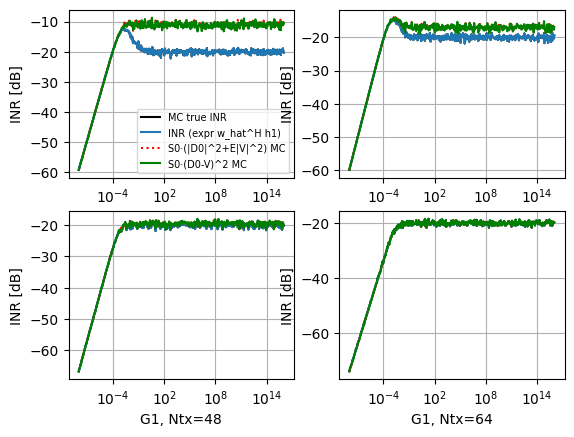

In [2]:
for idx, ntx in enumerate(ntx_num):

    mean_G_i       = G_i[idx, :]
    mean_INR_sim   = 10*np.log10(np.mean(inr[idx, :, :], axis=0))
    mean_INR_expr = 10*np.log10(np.mean(INR_expr[idx, :, :], axis=0))
    mean_INR_corr  = 10*np.log10(INR_theory_correct[idx, :])
    mean_INR_incorr  = 10*np.log10(INR_theory_incorrect[idx, :])
    mean_INR_SDV   = 10*np.log10(INR_from_SDV[idx, :])
    mean_INR_D2V2 = 10*np.log10(INR4_pow[idx, :])
    mean_INR_DV = 10*np.log10(INR5_pow[idx, :])

    plt.subplot(2, 2, idx + 1)
    plt.semilogx(mean_G_i, mean_INR_sim,   'k',  label='MC true INR')
    plt.semilogx(mean_G_i, mean_INR_expr, label='INR (expr w_hat^H h1)')
    # plt.semilogx(mean_G_i, mean_INR_corr,  'b--', label='Theory +')
    # plt.semilogx(mean_G_i, mean_INR_incorr,   'g-.', label='Theory -')
    # plt.semilogx(mean_G_i, mean_INR_SDV,   'g-.', label='SDV')
    plt.semilogx(mean_G_i, mean_INR_D2V2, 'r:', label='S0·(|D0|^2+E|V|^2) MC')
    plt.semilogx(mean_G_i, mean_INR_DV , 'g-', label='S0·(D0-V)^2 MC')

    plt.xlabel(f'G1, Ntx={ntx}')
    plt.ylabel('INR [dB]')
    plt.grid(True)
    if idx == 0:
        plt.legend(fontsize=7)


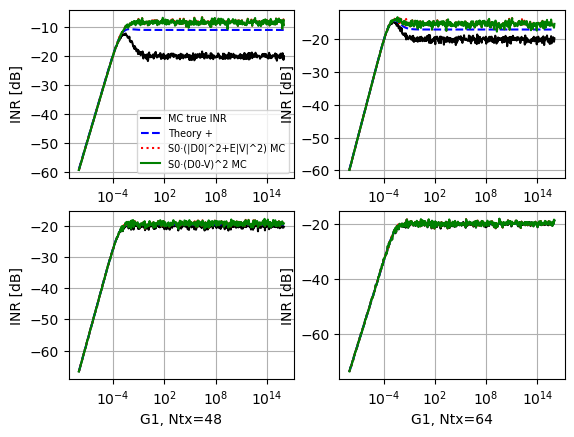

In [4]:
for idx, ntx in enumerate(ntx_num):

    mean_G_i       = G_i[idx, :]
    mean_INR_sim   = 10*np.log10(np.mean(inr[idx, :, :], axis=0))
    mean_INR_corr  = 10*np.log10(INR_theory_correct[idx, :])
    mean_INR_SDV   = 10*np.log10(INR_from_SDV[idx, :])
    mean_INR_D2V2 = 10*np.log10(INR4_pow[idx, :])
    mean_INR_DV = 10*np.log10(INR5_pow[idx, :])

    plt.subplot(2, 2, idx + 1)
    plt.semilogx(mean_G_i, mean_INR_sim,   'k',  label='MC true INR')
    plt.semilogx(mean_G_i, mean_INR_corr,  'b--', label='Theory +')
    # plt.semilogx(mean_G_i, mean_INR_SDV,   'g-.', label='Theory -')
    plt.semilogx(mean_G_i, mean_INR_D2V2, 'r:', label='S0·(|D0|^2+E|V|^2) MC')
    plt.semilogx(mean_G_i, mean_INR_DV , 'g-', label='S0·(D0-V)^2 MC')

    plt.xlabel(f'G1, Ntx={ntx}')
    plt.ylabel('INR [dB]')
    plt.grid(True)
    if idx == 0:
        plt.legend(fontsize=7)


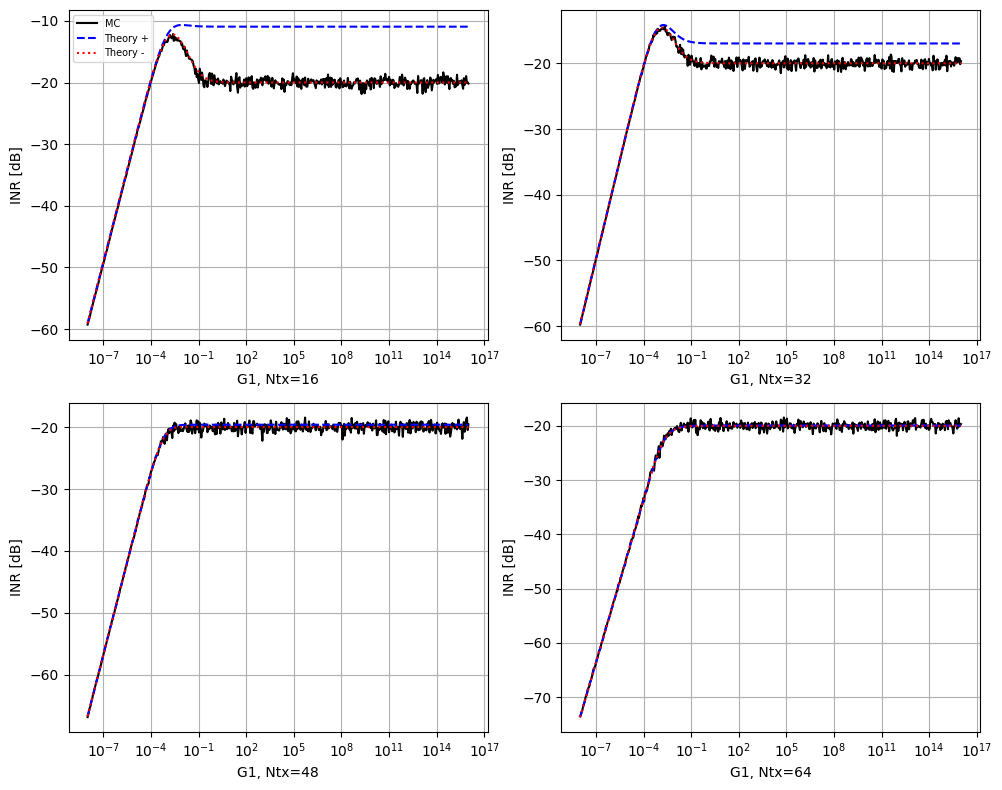

In [30]:

# ---------- Plot ----------
plt.figure(figsize=(10, 8))

for idx, ntx in enumerate(ntx_num):

    mean_G_i = G_i[idx, :]
    mean_INR_sim = 10 * np.log10(np.mean(inr[idx, :, :], axis=0))
    mean_INR_corr = 10 * np.log10(INR_theory_correct[idx, :])
    mean_INR_incorr = 10 * np.log10(INR_theory_incorrect[idx, :])
    mean_INR_SDV = 10 * np.log10(INR_from_SDV[idx, :])

    plt.subplot(2, 2, idx + 1)
    plt.semilogx(mean_G_i, mean_INR_sim, 'k', label='MC')
    plt.semilogx(mean_G_i, mean_INR_corr, 'b--', label='Theory +')
    plt.semilogx(mean_G_i, mean_INR_incorr, 'r:', label='Theory -')
    # plt.semilogx(mean_G_i, mean_INR_SDV, 'g-.', label='S(D+V)')

    plt.xlabel(f'G1, Ntx={ntx}')
    plt.ylabel('INR [dB]')
    plt.grid(True)

    if idx == 0:
        plt.legend(fontsize=7)

plt.tight_layout()
plt.show()


In [9]:
emp_var = np.mean(np.abs(V)**2)
theory_var = sigma_N1 / E_r
print(emp_var )
print(theory_var)

0.001187033366805953
0.001


In [ ]:
V.shape

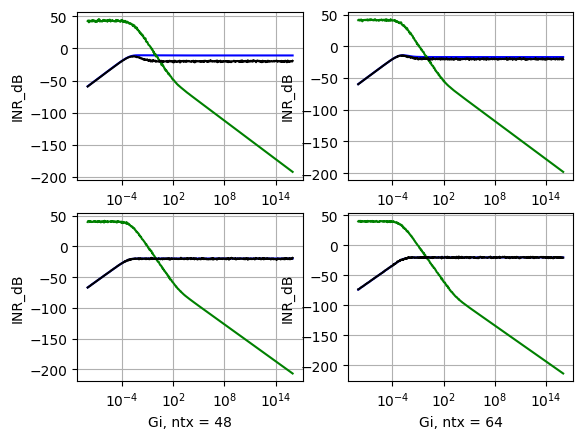

In [17]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR0_pow = 10*np.log10(np.mean(INR0_pow[n,:,:], axis=0))
    mean_INR2_pow = 10*np.log10(np.mean(INR2_pow[n,:,:], axis=0))
    mean_INR3_pow = 10*np.log10(np.mean(INR3_pow[n,:,:], axis=0))
    mean_INR4_pow = 10*np.log10(np.mean(INR4_pow[n,:,:], axis=0))
    mean_INR5_pow = 10*np.log10(np.mean(INR5_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))
    mean_INR_new = 10*np.log10(np.mean(INR_new[n,:,:], axis=0))



    plt.subplot(2,2,n+1)
    plt.semilogx(mean_G_i, mean_INR_theory_correct, color='blue', label='INR_theory_correct')
    # plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    plt.semilogx(mean_G_i, mean_INR3_pow, color='green', label='INR_pow')
    # plt.semilogx(mean_G_i, mean_INR2_pow, color='red', label='INR_pow')
    plt.semilogx(mean_G_i, mean_INR, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

In [ ]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR0_pow = 10*np.log10(np.mean(INR0_pow[n,:,:], axis=0))
    mean_INR2_pow = 10*np.log10(np.mean(INR2_pow[n,:,:], axis=0))
    mean_INR3_pow = 10*np.log10(np.mean(INR3_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))
    mean_INR_new = 10*np.log10(np.mean(INR_new[n,:,:], axis=0))



    plt.subplot(2,2,n+1)
    plt.semilogx(mean_G_i, mean_INR_theory_correct, color='blue', label='INR_theory_correct')
    plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    # plt.semilogx(mean_G_i, mean_INR_pow, color='green', label='INR_pow')
    plt.semilogx(mean_G_i, mean_INR3_pow, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

In [ ]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_INR_theory_correct = 10*np.log10(np.mean(INR_theory_correct[n,:,:], axis=0))
    mean_INR_theory_incorrect = 10*np.log10(np.mean(INR_theory_incorrect[n,:,:], axis=0))
    mean_INR_pow = 10*np.log10(np.mean(INR_pow[n,:,:], axis=0))
    mean_INR = 10*np.log10(np.mean(inr[n,:,:], axis=0))



    plt.subplot(2,3,n+1)
    plt.semilogx(mean_G_i, mean_INR, color='blue', label='mean_INR')
    plt.semilogx(mean_G_i, mean_INR_theory_incorrect, color='red', label='INR_theory_incorrect')
    # plt.semilogx(mean_G_i, mean_INR_pow, color='green', label='INR_pow')
    #plt.semilogx(mean_G_i, mean_INR, color='black', label='INR_pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('INR_dB')
    plt.grid()
plt.show()

In [ ]:
for n, ntx in enumerate(ntx_num):

    mean_G_i = np.mean(G_i[n,:,:], axis=0)
    mean_rho_hat_list= 10*np.log10(np.mean(rho_hat_list[n,:,:], axis=0))
    mean_rho_nom_abs2_list = 10*np.log10(np.mean(rho_nom_abs2_list[n,:,:], axis=0))



    plt.subplot(2,3,n+1)
    plt.semilogx(mean_G_i, mean_rho_hat_list, color='blue', label='Original h1 pow')
    plt.semilogx(mean_G_i, mean_rho_nom_abs2_list, color='red', label='Equalized h1 pow')
    plt.xlabel(f'Gi, ntx = {ntx}')
    plt.ylabel('rho_nom_abs2 in dB ')
    plt.grid()
plt.show()